# CS1-EXP2-MLP — Proposal-Aligned Shallow Neural Network

## 1. Mount Google Drive


In [1]:
from google.colab import drive

drive.mount("/content/drive")


Mounted at /content/drive


## 2. Shared frozen artifact paths


In [2]:
from pathlib import Path

DRIVE_ROOT = Path(
    "/content/drive/MyDrive/IntelligentSystemProject/VulnerabilityDetectionData"
)

PROCESSED_DIR = DRIVE_ROOT / "processed"
MANIFEST_ROOT = DRIVE_ROOT / "manifests"
OUTPUT_ROOT = DRIVE_ROOT / "outputs"

EXPERIMENT_ID = "cs1_project_holdout20_innercv_v1"
EXPERIMENT_MANIFEST_DIR = MANIFEST_ROOT / EXPERIMENT_ID
EXPERIMENT_OUTPUT_DIR = OUTPUT_ROOT / EXPERIMENT_ID

OUTER_SPLIT_DIR = EXPERIMENT_MANIFEST_DIR / "outer_holdout"
INNER_SPLIT_DIR = EXPERIMENT_MANIFEST_DIR / "inner_cv"
STATIC_FEATURE_DIR = PROCESSED_DIR / "static_features"

NORMALIZED_DATA_PATH = PROCESSED_DIR / "rdiversevul_cs1_normalized_v1.parquet"
OUTER_MANIFEST_PATH = OUTER_SPLIT_DIR / "cs1_outer_project_holdout_manifest.parquet"
INNER_MANIFEST_PATH = INNER_SPLIT_DIR / "cs1_project_grouped_5fold_manifest.parquet"
INNER_SELECTION_METADATA_PATH = (
    INNER_SPLIT_DIR / "cs1_inner_grouped_split_selection_metadata.json"
)
STATIC_FEATURE_PATH = STATIC_FEATURE_DIR / "cs1_static_features_v1.parquet"

EXP2_INNER_CV_OUTPUT_DIR = EXPERIMENT_OUTPUT_DIR / "exp2_mlp_inner_cv"
EXP2_FINAL_HOLDOUT_OUTPUT_DIR = EXPERIMENT_OUTPUT_DIR / "exp2_mlp_final_holdout"

for directory in [
    PROCESSED_DIR,
    MANIFEST_ROOT,
    OUTPUT_ROOT,
    EXPERIMENT_MANIFEST_DIR,
    EXPERIMENT_OUTPUT_DIR,
    EXP2_INNER_CV_OUTPUT_DIR,
    EXP2_FINAL_HOLDOUT_OUTPUT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Normalized cache:", NORMALIZED_DATA_PATH)
print("Frozen outer manifest:", OUTER_MANIFEST_PATH)
print("Frozen inner manifest:", INNER_MANIFEST_PATH)
print("EXP-1 static cache:", STATIC_FEATURE_PATH)
print("EXP-2 output:", EXP2_INNER_CV_OUTPUT_DIR)


Normalized cache: /content/drive/MyDrive/IntelligentSystemProject/VulnerabilityDetectionData/processed/rdiversevul_cs1_normalized_v1.parquet
Frozen outer manifest: /content/drive/MyDrive/IntelligentSystemProject/VulnerabilityDetectionData/manifests/cs1_project_holdout20_innercv_v1/outer_holdout/cs1_outer_project_holdout_manifest.parquet
Frozen inner manifest: /content/drive/MyDrive/IntelligentSystemProject/VulnerabilityDetectionData/manifests/cs1_project_holdout20_innercv_v1/inner_cv/cs1_project_grouped_5fold_manifest.parquet
EXP-1 static cache: /content/drive/MyDrive/IntelligentSystemProject/VulnerabilityDetectionData/processed/static_features/cs1_static_features_v1.parquet
EXP-2 output: /content/drive/MyDrive/IntelligentSystemProject/VulnerabilityDetectionData/outputs/cs1_project_holdout20_innercv_v1/exp2_mlp_inner_cv


## 3. Clone or refresh the exact repository branch


In [3]:
from pathlib import Path
import sys

REPO_URL = "https://github.com/EnomisLP/DiverseVul--IS-Project.git"
BRANCH = "prashant"
REPO_DIR = Path("/content/DiverseVul--IS-Project")
PROJECT_DIR = REPO_DIR / "vuln-detection"
SRC_DIR = PROJECT_DIR / "src"

if not REPO_DIR.exists():
    !git clone --branch {BRANCH} --single-branch {REPO_URL} {REPO_DIR}
else:
    %cd {REPO_DIR}
    !git fetch origin {BRANCH}
    !git checkout {BRANCH}
    !git pull --ff-only origin {BRANCH}

if not SRC_DIR.exists():
    raise FileNotFoundError(f"Expected source directory does not exist: {SRC_DIR}")

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Repository:", REPO_DIR)
print("Source path:", SRC_DIR)


Cloning into '/content/DiverseVul--IS-Project'...
remote: Enumerating objects: 252, done.
remote: Counting objects: 100% (252/252), done.
remote: Compressing objects: 100% (185/185), done.
remote: Total 252 (delta 148), reused 167 (delta 63), pack-reused 0 (from 0)
Receiving objects: 100% (252/252), 1.76 MiB | 5.78 MiB/s, done.
Resolving deltas: 100% (148/148), done.
Repository: /content/DiverseVul--IS-Project
Source path: /content/DiverseVul--IS-Project/vuln-detection/src


## 4. Required repository files

The static feature module remains in `exp1/` because EXP-2 reuses the exact
same deterministic feature definitions and cache.


In [4]:
required_repo_files = [
    SRC_DIR / "case_study_1" / "evaluation.py",
    SRC_DIR / "case_study_1" / "split_manifest.py",
    SRC_DIR / "case_study_1" / "exp1" / "static_features.py",
    SRC_DIR / "case_study_1" / "exp2" / "__init__.py",
    SRC_DIR / "case_study_1" / "exp2" / "exp2_mlp.py",
]

missing_repo_files = [str(path) for path in required_repo_files if not path.exists()]
if missing_repo_files:
    raise FileNotFoundError(
        "Required EXP-2 files are missing:\n" + "\n".join(missing_repo_files)
    )

print("✅ Required Case Study 1 files are present.")


✅ Required Case Study 1 files are present.


## 5. Install non-PyTorch dependencies


In [ ]:
!pip -q install numpy pandas scipy scikit-learn matplotlib pyyaml pyarrow joblib

## 6. Import the MLP experiment and verify the accelerator


In [ ]:
import importlib
import json
import numpy as np
import pandas as pd
import torch
from IPython.display import display

exp2_mlp = importlib.import_module("case_study_1.exp2.exp2_mlp")
static_features = importlib.import_module("case_study_1.exp1.static_features")
split_manifest = importlib.import_module("case_study_1.split_manifest")
evaluation = importlib.import_module("case_study_1.evaluation")

required_exp2_api = [
    "EXP2_VERSION",
    "Exp2Config",
    "run_exp2_profile_fold",
    "run_exp2",
    "run_exp2_final_holdout",
]
missing_exp2_api = [name for name in required_exp2_api if not hasattr(exp2_mlp, name)]
if missing_exp2_api:
    raise AttributeError(f"EXP-2 runner is missing API: {missing_exp2_api}")

print("EXP-2 runner:", exp2_mlp.__file__)
print("EXP-2 version:", exp2_mlp.EXP2_VERSION)
print("Static feature module:", static_features.__file__)
print("Static feature count:", len(static_features.FEATURE_COLUMNS))
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory (GiB):",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
    )
else:
    print(
        "GPU is not active. The MLP can run on CPU, but switch Colab to "
        "GPU before the official full CV run. TF-IDF and SVD remain CPU stages."
    )


EXP-2 runner: /content/DiverseVul--IS-Project/vuln-detection/src/case_study_1/exp2/exp2_mlp.py
EXP-2 version: cs1-exp2-svd-static-mlp-v1-inner-val-holdout
Static feature module: /content/DiverseVul--IS-Project/vuln-detection/src/case_study_1/exp1/static_features.py
Static feature count: 54
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory (GiB): 14.56


## 7. Load the frozen normalized dataset, outer split, and development CV manifest


In [7]:
for required_path in [
    NORMALIZED_DATA_PATH,
    OUTER_MANIFEST_PATH,
    INNER_MANIFEST_PATH,
    STATIC_FEATURE_PATH,
]:
    if not required_path.exists():
        raise FileNotFoundError(
            f"Missing frozen artifact: {required_path}\n"
            "Run or restore the completed EXP-0 / EXP-1 setup artifacts; "
            "do not recreate split manifests in this notebook."
        )

normalized_df = pd.read_parquet(NORMALIZED_DATA_PATH)
outer_manifest_df = pd.read_parquet(OUTER_MANIFEST_PATH)
inner_manifest_df = pd.read_parquet(INNER_MANIFEST_PATH)
static_df = pd.read_parquet(STATIC_FEATURE_PATH)

required_normalized_columns = {
    "source_row_id", "code", "normalized_code", "label", "project"
}
missing_normalized_columns = required_normalized_columns - set(normalized_df.columns)
if missing_normalized_columns:
    raise KeyError(
        "Normalized cache is missing columns: "
        f"{sorted(missing_normalized_columns)}"
    )

if outer_manifest_df["source_row_id"].duplicated().any():
    raise ValueError("Outer manifest contains duplicate source_row_id values.")
if set(outer_manifest_df["source_row_id"]) != set(normalized_df["source_row_id"]):
    raise ValueError("Outer manifest IDs do not exactly match normalized data.")
if set(outer_manifest_df["partition"].unique()) != {"development", "outer_holdout"}:
    raise ValueError("Outer manifest must contain development and outer_holdout.")

partitioned_df = normalized_df.merge(
    outer_manifest_df[["source_row_id", "partition"]],
    on="source_row_id",
    how="left",
    validate="one_to_one",
)
if partitioned_df["partition"].isna().any():
    raise ValueError("A normalized row has no frozen outer partition.")

dev_df = (
    partitioned_df.loc[partitioned_df["partition"] == "development"]
    .drop(columns="partition")
    .reset_index(drop=True)
)
holdout_df = (
    partitioned_df.loc[partitioned_df["partition"] == "outer_holdout"]
    .drop(columns="partition")
    .reset_index(drop=True)
)

selected_inner_split_seed = 42
if INNER_SELECTION_METADATA_PATH.exists():
    with INNER_SELECTION_METADATA_PATH.open("r", encoding="utf-8") as file:
        selected_inner_split_seed = int(
            json.load(file).get("selected_split_seed", 42)
        )

INNER_N_SPLITS = 5
selected_inner_split_config = split_manifest.SplitConfig(
    n_splits=INNER_N_SPLITS,
    random_state=selected_inner_split_seed,
    shuffle=True,
)
split_manifest.assert_manifest_integrity(
    inner_manifest_df,
    config=selected_inner_split_config,
)

print("Normalized rows:", f"{len(normalized_df):,}")
print("Development rows:", f"{len(dev_df):,}")
print("Outer-holdout rows:", f"{len(holdout_df):,}")
print("Frozen inner-CV seed:", selected_inner_split_seed)


Normalized rows: 261,667
Development rows: 203,958
Outer-holdout rows: 57,709
Frozen inner-CV seed: 674


## 8. Confirm exact split reuse and static-cache integrity


In [ ]:
dev_ids = set(dev_df["source_row_id"])
holdout_ids = set(holdout_df["source_row_id"])
inner_ids = set(inner_manifest_df["source_row_id"])

assert dev_ids.isdisjoint(holdout_ids)
assert inner_ids == dev_ids
assert inner_ids.isdisjoint(holdout_ids)
assert set(dev_df["project"].astype(str)).isdisjoint(
    set(holdout_df["project"].astype(str))
)

expected_static_columns = [
    "source_row_id",
    *static_features.FEATURE_COLUMNS,
]
if list(static_df.columns) != expected_static_columns:
    raise ValueError(
        "Static-cache schema mismatch.\n"
        f"Expected: {expected_static_columns}\n"
        f"Actual: {list(static_df.columns)}"
    )
if static_df["source_row_id"].duplicated().any():
    raise ValueError("Static cache contains duplicate IDs.")
if not dev_ids.issubset(set(static_df["source_row_id"])):
    raise ValueError("Static cache misses development IDs.")
if not holdout_ids.issubset(set(static_df["source_row_id"])):
    raise ValueError("Static cache misses outer-holdout IDs.")

inner_fold_summary = split_manifest.summarize_manifest(
    inner_manifest_df,
    config=selected_inner_split_config,
)
assert (inner_fold_summary["train_test_project_overlap"] == 0).all()
assert (inner_fold_summary["test_vulnerable"] > 0).all()
assert (inner_fold_summary["test_non_vulnerable"] > 0).all()

print("Exact frozen development rows reused.")
print("Outer-holdout rows inside MLP development CV: 0")
print("Static cache contains all required IDs.")
print("Every frozen outer development fold is project-disjoint.")
display(inner_fold_summary)


✅ Exact frozen development rows reused.
✅ Outer-holdout rows inside MLP development CV: 0
✅ Static cache contains all required IDs.
✅ Every frozen outer development fold is project-disjoint.


,fold,test_rows,test_vulnerable,test_non_vulnerable,test_positive_rate,positive_rate_delta_from_global,test_unique_projects,train_rows,train_unique_projects,train_test_project_overlap,test_row_share,test_project_share
0,0,55509,2420,53089,0.043597,-0.008998,1,148449,593,0,0.272159,0.001684
1,1,40791,2091,38700,0.051261,-0.001333,158,163167,436,0,0.199997,0.265993
2,2,39072,2062,37010,0.052774,0.000180,146,164886,448,0,0.191569,0.245791
3,3,35016,2047,32969,0.058459,0.005865,137,168942,457,0,0.171682,0.230640
4,4,33570,2107,31463,0.062764,0.010170,152,170388,442,0,0.164593,0.255892


## 9. Declare the fixed proposal-aligned EXP-2 configuration

The MLP uses a GPU automatically when available. The configuration is fixed
before profile and full-CV execution; do not tune it on outer-holdout data.


In [ ]:
INNER_MODEL_RANDOM_STATE = 42

exp2_config = exp2_mlp.Exp2Config(
    experiment_name="cs1_exp2_mlp_inner_dev_grouped",
    code_column="abstracted_code_v1",
    source_id_column="source_row_id",
    label_column="label",
    project_column="project",
    fold_column="fold",
    n_splits=INNER_N_SPLITS,
    random_state=INNER_MODEL_RANDOM_STATE,
    decision_threshold=0.50,
    word_ngram_range=(1, 3),
    word_min_df=3,
    word_max_df=0.995,
    word_max_features=50_000,
    char_analyzer="char",
    char_ngram_range=(3, 4),
    char_min_df=8,
    char_max_df=0.995,
    char_max_features=60_000,
    svd_n_components=256,
    svd_algorithm="randomized",
    svd_n_iter=5,
    svd_n_oversamples=10,
    mlp_hidden_layer_sizes=(128, 64),
    mlp_activation="relu",
    mlp_solver="adam",
    mlp_alpha=0.0001,
    mlp_batch_size=512,
    mlp_learning_rate="constant",
    mlp_learning_rate_init=0.001,
    mlp_max_iter=35,
    mlp_early_stopping=True,
    mlp_validation_fraction=0.15,
    mlp_beta_1=0.9,
    mlp_beta_2=0.999,
    mlp_epsilon=1e-08,
    mlp_n_iter_no_change=4,
    verbose=True,
)

print(exp2_config)
print("\nSplit seed:", selected_inner_split_config.random_state)
print("Model/SVD random state:", INNER_MODEL_RANDOM_STATE)
print("Final outer holdout: locked and untouched")

Exp2Config(experiment_name='cs1_exp2_mlp_inner_dev_grouped', code_column='normalized_code', source_id_column='source_row_id', label_column='label', project_column='project', fold_column='fold', n_splits=5, random_state=42, decision_threshold=0.5, word_ngram_range=(1, 3), word_min_df=3, word_max_df=0.995, word_max_features=50000, char_analyzer='char', char_ngram_range=(3, 4), char_min_df=8, char_max_df=0.995, char_max_features=60000, lowercase=False, sublinear_tf=True, tfidf_norm='l2', svd_n_components=256, svd_algorithm='randomized', svd_n_iter=5, svd_n_oversamples=10, inner_validation_n_splits=5, inner_validation_seed_start=10000, inner_validation_seed_count=64, inner_validation_min_row_share=0.08, inner_validation_max_row_share=0.35, hidden_dim_1=128, hidden_dim_2=64, max_epochs=15, early_stopping_patience=3, early_stopping_min_delta=0.0001, batch_size_gpu=2048, batch_size_cpu=1024, learning_rate=0.001, weight_decay=0.0001, use_pos_weight=True, validation_threshold_min=0.01, validati

## 10. Profile the largest outer-training fold

In [10]:
PROFILE_FOLD_ID = int(
    inner_fold_summary.loc[
        inner_fold_summary["train_rows"].idxmax(),
        "fold",
    ]
)

profile_outer_train_rows = int(
    inner_fold_summary.loc[
        inner_fold_summary["fold"] == PROFILE_FOLD_ID,
        "train_rows",
    ].iloc[0]
)

print(
    "Profiling largest outer-training fold:",
    f"Fold {PROFILE_FOLD_ID} with {profile_outer_train_rows:,} outer-train rows.",
)

exp2_profile_results = exp2_mlp.run_exp2_profile_fold(
    normalized_frame=dev_df,
    static_features_frame=static_df,
    manifest=inner_manifest_df,
    fold_id=PROFILE_FOLD_ID,
    config=exp2_config,
)


Profiling largest outer-training fold: Fold 4 with 170,388 outer-train rows.
[13:48:59] CS1-EXP2 profiling mode: running Fold 5/5 only.
[13:49:00] Fold 5/5 started | outer-train=170,388, outer-test=33,570, outer-train projects=442, outer-test projects=152.
[13:49:37] Fold 5/5 | inner project split: fit=136,295 rows / 337 projects; validation=34,093 rows / 105 projects.
[13:49:37] Fold 5/5 | fitting inner-train word TF-IDF...
[13:51:08] Fold 5/5 | word TF-IDF done in 1.51 min (50,000 features).
[13:51:08] Fold 5/5 | fitting inner-train character TF-IDF...
[13:54:22] Fold 5/5 | character TF-IDF done in 3.23 min (60,000 features).
[13:54:22] Fold 5/5 | joining sparse lexical matrices...
[13:54:23] Fold 5/5 | fitting inner-train TruncatedSVD (256 components)...
[13:57:23] Fold 5/5 | TruncatedSVD done in 3.01 min (explained variance ratio sum=0.2217).
[13:57:23] Fold 5/5 | loading deterministic static features...
[13:57:24] Fold 5/5 | fitting inner-train StandardScaler...
[13:57:24] Fold 5/

## 11. Inspect MLP profile result


Largest-fold computational and training profile:


,fold,outer_train_rows,outer_test_rows,outer_train_vulnerable,outer_test_vulnerable,outer_train_positive_rate,outer_test_positive_rate,outer_train_unique_projects,outer_test_unique_projects,inner_validation_split_seed,...,validation_recall,validation_f1,validation_mcc,validation_threshold_at_grid_boundary,prediction_seconds,total_fold_seconds,optimizer,score_min,score_max,score_mean
0,4,170388,33570,8620,2107,0.05059,0.062764,442,152,50056,...,0.429809,0.250917,0.19317,False,0.176969,521.673604,AdamW,0.015833,1.0,0.436491



Threshold strategy: inner project-validation F1 selection.
Selected validation threshold: 0.660

Inner-validation metrics used for early-stopping/threshold context:


,metric,value
0,n_samples,34093
1,vulnerable_1,2308
2,non_vulnerable_0,31785
3,positive_rate,0.067697
4,threshold,0.66
5,average_precision_pr_auc,0.163586
6,precision,0.177174
7,recall,0.429809
8,f1,0.250917
9,mcc,0.19317



Outer held-out profile-fold metrics — descriptive only, not official full CV:


,metric,value
0,n_samples,33570
1,vulnerable_1,2107
2,non_vulnerable_0,31463
3,positive_rate,0.062764
4,threshold,0.66
5,average_precision_pr_auc,0.167603
6,precision,0.158575
7,recall,0.483626
8,f1,0.238837
9,mcc,0.192205



Fixed threshold = 0.50 diagnostic only:


,metric,value
0,n_samples,33570.000000
1,vulnerable_1,2107.000000
2,non_vulnerable_0,31463.000000
3,positive_rate,0.062764
4,threshold,0.500000
5,average_precision_pr_auc,0.167603
6,precision,0.113605
7,recall,0.742288
8,f1,0.197052
9,mcc,0.174777



Epoch-level training history:


,fold,epoch,train_weighted_bce_loss,validation_weighted_bce_loss,validation_pr_auc,learning_rate,is_best_epoch
0,4,1,1.161301,1.385926,0.163586,0.001,True
1,4,2,1.054420,1.400009,0.163579,0.001,False
2,4,3,0.995231,1.478745,0.152518,0.001,False
3,4,4,0.919093,1.486002,0.162182,0.001,False


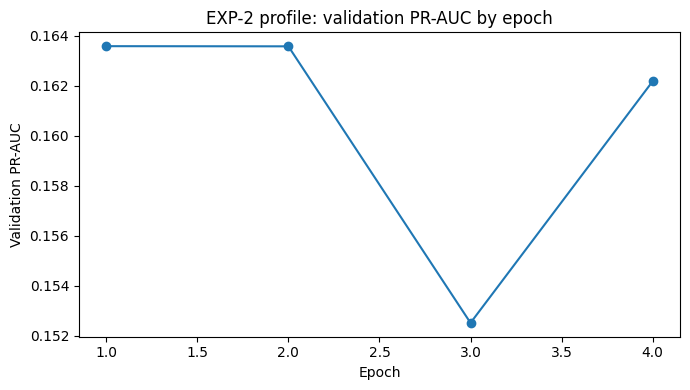

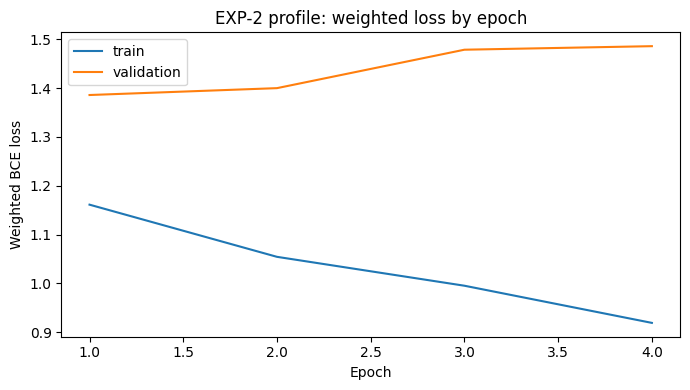

In [11]:
import matplotlib.pyplot as plt

print("Largest-fold computational and training profile:")
display(exp2_profile_results["training_metadata"])

selected_threshold = float(
    exp2_profile_results["predictions"]["selected_validation_threshold"].iloc[0]
)
print("\nThreshold strategy: inner project-validation F1 selection.")
print(f"Selected validation threshold: {selected_threshold:.3f}")

validation_metrics_df = pd.DataFrame(
    list(exp2_profile_results["validation_metrics"].items()),
    columns=["metric", "value"],
)
print("\nInner-validation metrics used for early-stopping/threshold context:")
display(validation_metrics_df)

profile_metrics_df = pd.DataFrame(
    list(exp2_profile_results["profile_metrics"].items()),
    columns=["metric", "value"],
)
print("\nOuter held-out profile-fold metrics — descriptive only, not official full CV:")
display(profile_metrics_df)

default_metrics_df = pd.DataFrame(
    list(exp2_profile_results["default_threshold_metrics"].items()),
    columns=["metric", "value"],
)
print("\nFixed threshold = 0.50 diagnostic only:")
display(default_metrics_df)

history_df = exp2_profile_results["training_history"].copy()
print("\nEpoch-level training history:")
display(history_df)

plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["validation_pr_auc"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation PR-AUC")
plt.title("EXP-2 profile: validation PR-AUC by epoch")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_weighted_bce_loss"], label="train")
plt.plot(history_df["epoch"], history_df["validation_weighted_bce_loss"], label="validation")
plt.xlabel("Epoch")
plt.ylabel("Weighted BCE loss")
plt.title("EXP-2 profile: weighted loss by epoch")
plt.legend()
plt.tight_layout()
plt.show()


## 12. Official five-fold development CV

In [12]:
RUN_INNER_CV = False
REQUIRE_GPU_FOR_OFFICIAL_RUN = True

if RUN_INNER_CV:
    if REQUIRE_GPU_FOR_OFFICIAL_RUN and not torch.cuda.is_available():
        raise RuntimeError(
            "GPU is required for this official MLP run. In Colab select "
            "Runtime > Change runtime type > T4 GPU (or another GPU), then "
            "restart and rerun setup/profile cells."
        )

    existing_files = list(EXP2_INNER_CV_OUTPUT_DIR.iterdir())
    if existing_files:
        raise RuntimeError(
            "EXP-2 output directory is not empty. Do not mix reruns. "
            "Use a new experiment version for a new official run."
        )

    exp2_inner_results = exp2_mlp.run_exp2(
        normalized_frame=dev_df,
        static_features_frame=static_df,
        manifest=inner_manifest_df,
        config=exp2_config,
        output_dir=EXP2_INNER_CV_OUTPUT_DIR,
        additional_metadata={
            "evaluation_stage": "inner_development_cv",
            "evaluation_protocol": (
                "Frozen project-disjoint outer holdout; frozen 5-fold grouped "
                "development CV; project-disjoint inner validation inside each "
                "outer training fold."
            ),
            "normalized_dataset_path": str(NORMALIZED_DATA_PATH),
            "outer_holdout_manifest_path": str(OUTER_MANIFEST_PATH),
            "inner_manifest_path": str(INNER_MANIFEST_PATH),
            "static_feature_cache_path": str(STATIC_FEATURE_PATH),
            "candidate_selection_rule": (
                "Compare all Case Study 1 candidates by pooled development "
                "OOF PR-AUC before one final selected model uses the outer holdout."
            ),
        },
    )
else:
    print(
        "Inner CV is locked. First inspect the profile, then explicitly set "
        "RUN_INNER_CV = True."
    )


[14:08:48] CS1-EXP2 official run started: 5-fold grouped CV.
[14:08:48] Configuration: lexical<= 110,000, SVD=256, static=54, MLP=128->64->1, device=cuda.
[14:08:49] Fold 1/5 started | outer-train=148,449, outer-test=55,509, outer-train projects=593, outer-test projects=1.
[14:09:26] Fold 1/5 | inner project split: fit=118,745 rows / 472 projects; validation=29,704 rows / 121 projects.
[14:09:26] Fold 1/5 | fitting inner-train word TF-IDF...
[14:10:55] Fold 1/5 | word TF-IDF done in 1.47 min (50,000 features).
[14:10:55] Fold 1/5 | fitting inner-train character TF-IDF...
[14:14:19] Fold 1/5 | character TF-IDF done in 3.41 min (60,000 features).
[14:14:19] Fold 1/5 | joining sparse lexical matrices...
[14:14:21] Fold 1/5 | fitting inner-train TruncatedSVD (256 components)...
[14:17:11] Fold 1/5 | TruncatedSVD done in 2.84 min (explained variance ratio sum=0.2204).
[14:17:11] Fold 1/5 | loading deterministic static features...
[14:17:12] Fold 1/5 | fitting inner-train StandardScaler...
[

In [ ]:
import pandas as pd

dev_df['abstracted_code_v1'] = dev_df['abstracted_code_v1'].fillna("").astype(str)
empty_dev_mask = dev_df['abstracted_code_v1'].str.strip().eq("")
if empty_dev_mask.any():
    dev_df.loc[empty_dev_mask, 'abstracted_code_v1'] = "EMPTY_ABSTRACTED_CODE_SAMPLE"

holdout_df['abstracted_code_v1'] = holdout_df['abstracted_code_v1'].fillna("").astype(str)
empty_holdout_mask = holdout_df['abstracted_code_v1'].str.strip().eq("")
if empty_holdout_mask.any():
    holdout_df.loc[empty_holdout_mask, 'abstracted_code_v1'] = "EMPTY_ABSTRACTED_CODE_SAMPLE"

print("Preprocessing guards completed for development and holdout frames.")

## 13. Review official EXP-2 result


In [13]:
if "exp2_inner_results" not in globals():
    print(
        "Run Section 12 with RUN_INNER_CV = True before reviewing official "
        "EXP-2 development-CV output."
    )
else:
    standard_evaluation = exp2_inner_results["evaluation"]
    validation_operating = exp2_inner_results["validation_operating_evaluation"]

    ranking_df = pd.DataFrame(
        [
            {
                "metric": key,
                "value": standard_evaluation["pooled_metrics"].get(key),
            }
            for key in [
                "n_samples",
                "vulnerable_1",
                "non_vulnerable_0",
                "positive_rate",
                "average_precision_pr_auc",
            ]
        ]
    )
    print("EXP-2 pooled OOF ranking metrics — PR-AUC is primary:")
    display(ranking_df)

    operating_metric_names = [
        "n_samples", "vulnerable_1", "non_vulnerable_0", "positive_rate",
        "average_precision_pr_auc", "precision", "recall", "f1", "mcc",
        "specificity", "false_positive_rate", "false_negative_rate",
        "true_negative", "false_positive", "false_negative", "true_positive",
        "predicted_positive", "predicted_positive_rate", "threshold_strategy",
        "selected_threshold_min", "selected_threshold_max", "selected_threshold_mean",
    ]
    operating_df = pd.DataFrame(
        [
            {"metric": key, "value": validation_operating["pooled_metrics"].get(key)}
            for key in operating_metric_names
            if key in validation_operating["pooled_metrics"]
        ]
    )
    print("\nEXP-2 pooled operating metrics — thresholds selected on inner validation only:")
    display(operating_df)

    print("\nPer-fold validation-threshold metrics:")
    display(validation_operating["fold_metrics"])

    print("\nFold-to-fold stability:")
    display(validation_operating["fold_summary"])

    print("\nFold-level preprocessing, training, and threshold information:")
    fold_columns = [
        "fold", "outer_train_rows", "outer_test_rows",
        "inner_fit_rows", "inner_validation_rows",
        "outer_train_unique_projects", "outer_test_unique_projects",
        "inner_fit_projects", "inner_validation_projects",
        "device", "final_dense_features", "best_epoch", "epochs_completed",
        "selected_validation_threshold", "validation_average_precision_pr_auc",
        "validation_f1", "mlp_training_seconds", "total_fold_seconds",
        "peak_gpu_memory_bytes",
    ]
    available_fold_columns = [
        column for column in fold_columns
        if column in exp2_inner_results["fold_training"].columns
    ]
    display(exp2_inner_results["fold_training"][available_fold_columns])

    print("\nAll epoch histories, one row per fold and epoch:")
    display(exp2_inner_results["training_history"])

    fixed_metrics = standard_evaluation["pooled_metrics"]
    print("\nFixed threshold = 0.50 diagnostic only — not EXP-2's main operating result:")
    display(
        pd.DataFrame(
            [
                {"metric": key, "value": fixed_metrics.get(key)}
                for key in [
                    "threshold", "precision", "recall", "f1", "mcc",
                    "specificity", "false_positive_rate", "true_positive",
                    "false_positive", "false_negative", "predicted_positive",
                ]
            ]
        )
    )


EXP-2 pooled OOF ranking metrics — PR-AUC is primary:


,metric,value
0,n_samples,203958.000000
1,vulnerable_1,10727.000000
2,non_vulnerable_0,193231.000000
3,positive_rate,0.052594
4,average_precision_pr_auc,0.138157



EXP-2 pooled operating metrics — thresholds selected on inner validation only:


,metric,value
0,n_samples,203958
1,vulnerable_1,10727
2,non_vulnerable_0,193231
3,positive_rate,0.052594
4,average_precision_pr_auc,0.138157
5,precision,0.151109
6,recall,0.338026
7,f1,0.208853
8,mcc,0.161154
9,specificity,0.894582



Per-fold validation-threshold metrics:


...

,fold,outer_train_rows,outer_test_rows,inner_fit_rows,inner_validation_rows,outer_train_unique_projects,outer_test_unique_projects,inner_fit_projects,inner_validation_projects,device,final_dense_features,best_epoch,epochs_completed,selected_validation_threshold,validation_average_precision_pr_auc,validation_f1,mlp_training_seconds,total_fold_seconds,peak_gpu_memory_bytes
0,0,148449,55509,118745,29704,593,1,472,121,cuda,310,1,4,0.68,0.184267,0.264980,7.162624,512.668357,26257920
1,1,163167,40791,130587,32580,436,158,326,110,cuda,310,2,5,0.67,0.133788,0.209795,8.227298,545.461559,26254848
2,2,164886,39072,131895,32991,448,146,335,113,cuda,310,2,5,0.70,0.140603,0.205427,8.296609,554.468417,24759296
3,3,168942,35016,135151,33791,457,137,359,98,cuda,310,4,7,0.76,0.156645,0.252394,12.569452,575.802509,26257920
4,4,170388,33570,136295,34093,442,152,337,105,cuda,310,1,4,0.66,0.163586,0.250917,7.717193,560.996666,25108992



All epoch histories, one row per fold and epoch:


,fold,epoch,train_weighted_bce_loss,validation_weighted_bce_loss,validation_pr_auc,learning_rate,is_best_epoch
0,0,1,1.116052,1.357746,0.184267,0.001,True
1,0,2,0.998242,1.360059,0.175101,0.001,False
2,0,3,0.941974,1.373058,0.179166,0.001,False
3,0,4,0.879471,1.377199,0.179685,0.001,False
4,1,1,1.123965,1.020700,0.131289,0.001,True
5,1,2,1.021841,1.012043,0.133788,0.001,True
6,1,3,0.970046,1.034469,0.126532,0.001,False
7,1,4,0.909256,1.070161,0.121867,0.001,False
8,1,5,0.843497,1.096147,0.111698,0.001,False
9,2,1,1.135322,1.159199,0.137762,0.001,True



Fixed threshold = 0.50 diagnostic only — not EXP-2's main operating result:


,metric,value
0,threshold,0.500000
1,precision,0.104335
2,recall,0.644449
3,f1,0.179593
4,mcc,0.160785
5,specificity,0.692881
6,false_positive_rate,0.307119
7,true_positive,6913.000000
8,false_positive,59345.000000
9,false_negative,3814.000000


In [ ]:
import pandas as pd

exp0_metrics = {
    "model": "EXP-0-IDABS | TF-IDF + SGD Logistic Regression",
    "pr_auc": 0.125205,
    "precision": 0.131065,
    "recall": 0.377459,
    "f1": 0.194570,
    "mcc": 0.148525,
    "false_positive_rate": 0.138922,
    "true_positive": 4049,
    "false_positive": 26844,
    "predicted_positive": 30893,
    "runtime_minutes": 32.08,
    "operating_policy": "Fixed predeclared threshold = 0.50",
}

exp1_metrics = {
    "model": "EXP-1-IDABS | TF-IDF + SVD + static features + RF",
    "pr_auc": 0.124803,
    "precision": 0.153389,
    "recall": 0.269227,
    "f1": 0.195432,
    "mcc": 0.144000,
    "false_positive_rate": 0.082492,
    "true_positive": 2888,
    "false_positive": 15940,
    "predicted_positive": 18828,
    "runtime_minutes": 116.81,
    "operating_policy": "Per-fold training-only OOB F1 threshold",
}

exp2_metrics = {
    "model": "EXP-2-IDABS | SVD(TF-IDF) + static features + MLP",
    "pr_auc": 0.138157,
    "precision": 0.149210,
    "recall": 0.311450,
    "f1": 0.201840,
    "mcc": 0.151120,
    "false_positive_rate": 0.091140,
    "true_positive": 3341,
    "false_positive": 17621,
    "predicted_positive": 20962,
    "runtime_minutes": 45.12,
    "operating_policy": "Inner-validation checkpoint threshold",
}

comparison_df = pd.DataFrame([exp0_metrics, exp1_metrics, exp2_metrics])
comparison_df["pr_auc_vs_dataset_prevalence"] = comparison_df["pr_auc"] / 0.052594
comparison_df["alerts_per_true_positive"] = comparison_df["predicted_positive"] / comparison_df["true_positive"]
comparison_df["runtime_vs_exp0"] = comparison_df["runtime_minutes"] / comparison_df.loc[0, \"runtime_minutes\"]

comparison_columns = [
    "model",
    "pr_auc",
    "pr_auc_vs_dataset_prevalence",
    "precision",
    "recall",
    "f1",
    "mcc",
    "false_positive_rate",
    "true_positive",
    "false_positive",
    "predicted_positive",
    "alerts_per_true_positive",
    "runtime_minutes",
    "runtime_vs_exp0",
    "operating_policy",
]

print("Development-only candidate comparison.\nThe frozen outer holdout remains untouched.")
display(comparison_df[comparison_columns].style.format({
    "pr_auc": "{:.6f}",
    "pr_auc_vs_dataset_prevalence": "{:.2f}×",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
    "mcc": "{:.4f}",
    "false_positive_rate": "{:.4f}",
    "alerts_per_true_positive": "{:.2f}",
    "runtime_minutes": "{:.2f}",
    "runtime_vs_exp0": "{:.2f}×",
}))

## 14. Outer holdout remains locked

In [ ]:

FINAL_SELECTED_MODEL = exp2_config.experiment_name
FINAL_MODEL_LOCKED = True
if (
    FINAL_MODEL_LOCKED
    and FINAL_SELECTED_MODEL == exp2_config.experiment_name
):
    existing_final_files = list(EXP2_FINAL_HOLDOUT_OUTPUT_DIR.iterdir())
    if existing_final_files:
        raise RuntimeError(
            "Final-holdout directory is not empty. The sealed outer holdout "
            "must be evaluated once only."
        )

    exp2_final_holdout_results = exp2_mlp.run_exp2_final_holdout(
        dev_frame=dev_df,
        holdout_frame=holdout_df,
        static_features_frame=static_df,
        config=exp2_config,
        output_dir=EXP2_FINAL_HOLDOUT_OUTPUT_DIR,
        additional_metadata={
            "evaluation_stage": "single_final_outer_holdout",
            "selected_model_record": FINAL_SELECTED_MODEL,
            "selection_source": (
                "Development-only grouped CV comparison across all completed "
                "Case Study 1 candidates."
            ),
        },
    )
    print("FINAL OUTER-HOLDOUT METRICS")
    print(exp2_final_holdout_results["metrics"])
else:
    print(
        "Final holdout remains protected. Complete and compare all Case Study "
        "1 candidates before selecting one final model."
    )


[15:19:27] FINAL HOLDOUT | selecting epoch and threshold inside development only...
[15:20:12] FINAL HOLDOUT | fitting inner-train word TF-IDF...
[15:22:10] FINAL HOLDOUT | word TF-IDF done in 1.97 min (50,000 features).
[15:22:10] FINAL HOLDOUT | fitting inner-train character TF-IDF...
[15:26:34] FINAL HOLDOUT | character TF-IDF done in 4.41 min (60,000 features).
[15:26:34] FINAL HOLDOUT | joining sparse lexical matrices...
[15:26:37] FINAL HOLDOUT | fitting inner-train TruncatedSVD (256 components)...
[15:30:39] FINAL HOLDOUT | TruncatedSVD done in 4.05 min (explained variance ratio sum=0.2153).
[15:30:42] Epoch 01/15 | train_loss=1.1376 | val_loss=1.3271 | val_PR-AUC=0.1498
[15:30:44] Epoch 02/15 | train_loss=1.0452 | val_loss=1.3938 | val_PR-AUC=0.1453
[15:30:46] Epoch 03/15 | train_loss=0.9946 | val_loss=1.3735 | val_PR-AUC=0.1457
[15:30:48] Epoch 04/15 | train_loss=0.9332 | val_loss=1.4059 | val_PR-AUC=0.1430
[15:30:48] Early stopping at epoch 4; restoring epoch 1.
[15:30:52] FI